# RFM Analysis & Customer Segmentation with K-Means

**Objective:** Segment customers using RFM (Recency, Frequency, Monetary) metrics, then apply K-Means clustering to discover natural customer groups for targeted marketing.

**Pipeline:**
1. Compute RFM scores per customer
2. Assign traditional RFM segments
3. Apply K-Means clustering on scaled RFM features
4. Profile and visualize each cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

## 1. Load Data

In [2]:
df = pd.read_csv("../data/processed/fact_orders.csv", parse_dates=["order_date"])

# RFM only considers completed orders
completed = df[df["order_status"] == "Completed"].copy()
print(f"Completed orders: {completed.shape[0]:,}")
print(f"Unique customers: {completed['customer_id'].nunique():,}")
print(f"Date range: {completed['order_date'].min().date()} → {completed['order_date'].max().date()}")

Completed orders: 6,704
Unique customers: 4,771
Date range: 2023-09-24 → 2024-09-23


## 2. Compute RFM Metrics

- **Recency:** Days since last purchase (lower = better)
- **Frequency:** Number of completed orders
- **Monetary:** Total revenue from completed orders

In [3]:
snapshot_date = completed["order_date"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = (
    completed
    .groupby("customer_id")
    .agg(
        recency=("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("revenue", "sum"),
    )
    .reset_index()
)

print(f"\nRFM table: {rfm.shape[0]:,} customers")
rfm.describe().round(2)

Snapshot date: 2024-09-24

RFM table: 4,771 customers


,customer_id,recency,frequency,monetary
count,4771.00,4771.00,4771.00,4771.00
mean,5502.60,163.01,1.41,3467.46
std,2608.86,104.18,0.67,2659.29
min,1000.00,1.00,1.00,129.83
25%,3258.50,73.00,1.00,1287.97
50%,5479.00,152.00,1.00,2958.35
75%,7777.00,249.00,2.00,4883.50
max,9998.00,366.00,6.00,18993.35


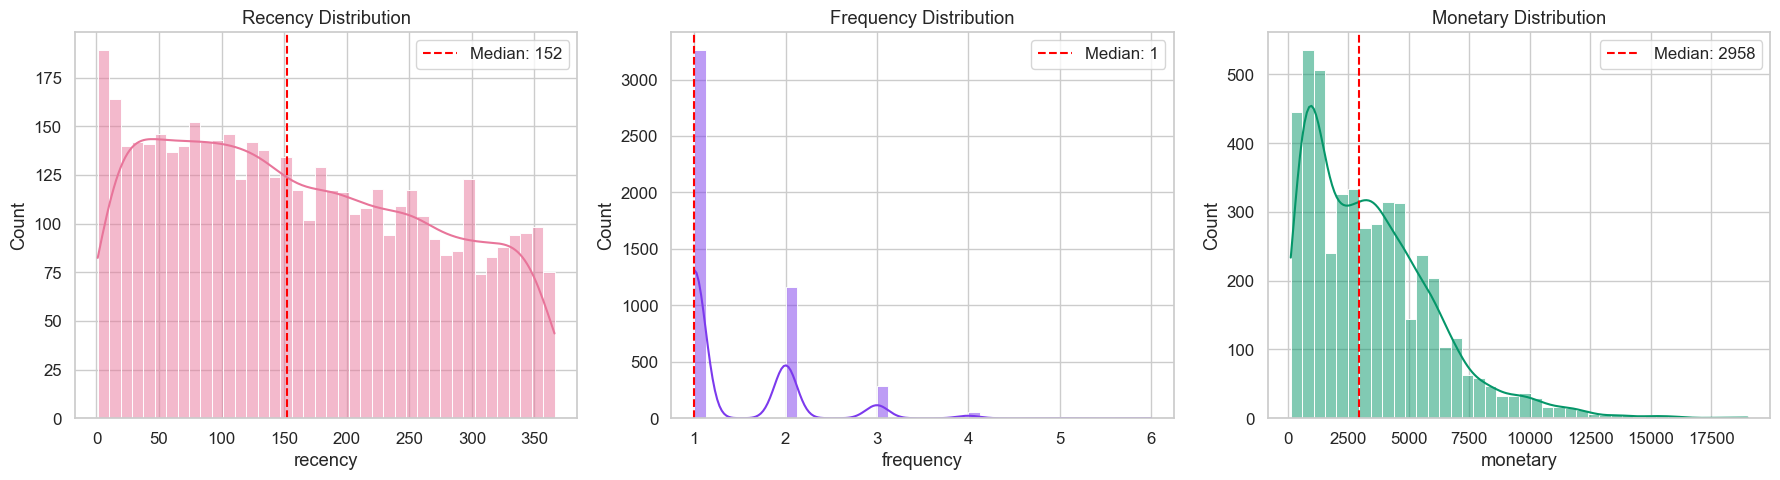

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, ["recency", "frequency", "monetary"], ["#e8759a", "#7c3aed", "#059669"]):
    sns.histplot(rfm[col], bins=40, kde=True, color=color, ax=ax)
    ax.axvline(rfm[col].median(), color="red", linestyle="--", label=f"Median: {rfm[col].median():.0f}")
    ax.set_title(f"{col.capitalize()} Distribution")
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Traditional RFM Scoring (Quintile-based)

In [6]:
# Score 1-5 using quintiles (5 = best)
rfm["r_score"] = pd.qcut(rfm["recency"], q=5, labels=[5, 4, 3, 2, 1])  # lower recency = higher score
rfm["f_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
rfm["m_score"] = pd.qcut(rfm["monetary"], q=5, labels=[1, 2, 3, 4, 5])

rfm["r_score"] = rfm["r_score"].astype(int)
rfm["f_score"] = rfm["f_score"].astype(int)
rfm["m_score"] = rfm["m_score"].astype(int)

rfm["rfm_score"] = rfm["r_score"] * 100 + rfm["f_score"] * 10 + rfm["m_score"]
rfm["rfm_combined"] = rfm["r_score"].astype(str) + rfm["f_score"].astype(str) + rfm["m_score"].astype(str)

rfm.head(10)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_combined
0,1000,157,1,1100.94,3,1,2,312,312
1,1002,46,2,5151.88,5,4,4,544,544
2,1003,126,1,976.70,3,1,1,311,311
3,1004,121,1,1953.40,3,1,2,312,312
4,1005,92,2,7395.39,4,4,5,445,445
5,1006,91,2,9896.72,4,4,5,445,445
6,1008,365,1,519.32,1,1,1,111,111
7,1011,79,1,5960.90,4,1,5,415,415
8,1014,129,1,3576.54,3,1,3,313,313
9,1015,22,1,1953.40,5,1,2,512,512


In [7]:
def assign_segment(row):
    r, f, m = row["r_score"], row["f_score"], row["m_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r >= 3 and f >= 1 and m >= 2:
        return "Potential Loyalists"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r <= 2 and f >= 4:
        return "Can't Lose Them"
    elif r <= 2 and f <= 2:
        return "Hibernating"
    else:
        return "Need Attention"

rfm["segment"] = rfm.apply(assign_segment, axis=1)
rfm["segment"].value_counts()

segment
Hibernating            934
Champions              694
Loyal Customers        673
New Customers          607
Need Attention         585
At Risk                579
Potential Loyalists    546
Can't Lose Them        153
Name: count, dtype: int64

In [8]:
seg_summary = (
    rfm.groupby("segment")
    .agg(
        count=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
    )
    .sort_values("avg_monetary", ascending=False)
    .round(1)
)
seg_summary["pct"] = (seg_summary["count"] / seg_summary["count"].sum() * 100).round(1)
seg_summary

,count,avg_recency,avg_frequency,avg_monetary,pct
segment,,,,,
Champions,694,54.5,2.4,6926.0,14.5
At Risk,579,264.9,1.5,4891.4,12.1
Loyal Customers,673,112.8,1.7,4673.8,14.1
Hibernating,934,277.6,1.0,2517.4,19.6
Potential Loyalists,546,123.2,1.2,2414.1,11.4
New Customers,607,62.7,1.0,2353.4,12.7
Can't Lose Them,153,270.8,1.4,1258.1,3.2
Need Attention,585,178.6,1.1,801.0,12.3


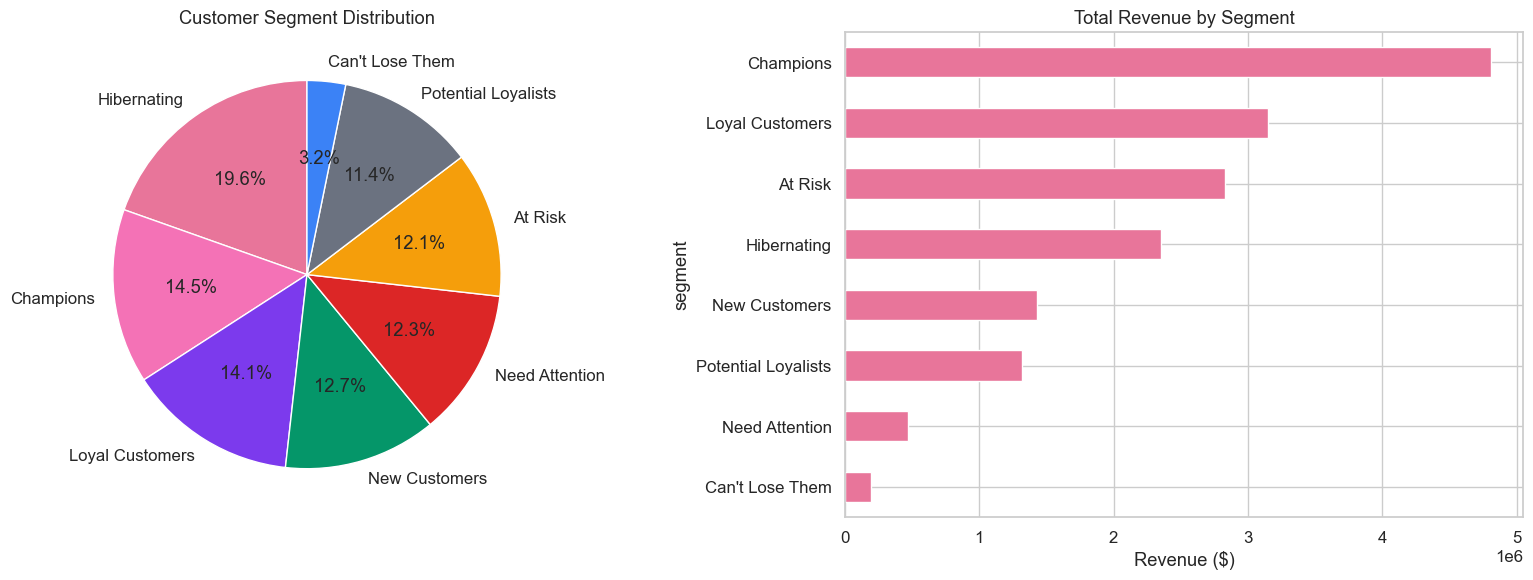

In [9]:
colors_seg = ["#e8759a", "#f472b6", "#7c3aed", "#059669", "#dc2626", "#f59e0b", "#6b7280", "#3b82f6"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_counts = rfm["segment"].value_counts()
axes[0].pie(
    seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
    colors=colors_seg[:len(seg_counts)], startangle=90, wedgeprops={"edgecolor": "white"}
)
axes[0].set_title("Customer Segment Distribution")

seg_rev = rfm.groupby("segment")["monetary"].sum().sort_values(ascending=True)
seg_rev.plot(kind="barh", color="#e8759a", ax=axes[1])
axes[1].set_title("Total Revenue by Segment")
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.show()

## 4. K-Means Clustering on RFM

Let the data speak — find natural groupings without predefined rules.

In [10]:
# Log-transform monetary & frequency to reduce skewness
rfm_features = rfm[["recency", "frequency", "monetary"]].copy()
rfm_features["monetary"] = np.log1p(rfm_features["monetary"])
rfm_features["frequency"] = np.log1p(rfm_features["frequency"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_features)

print("Scaled feature stats:")
pd.DataFrame(X_scaled, columns=["recency", "frequency", "monetary"]).describe().round(2)

Scaled feature stats:


,recency,frequency,monetary
count,4771.00,4771.00,4771.00
mean,0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.56,-0.64,-3.08
25%,-0.86,-0.64,-0.67
50%,-0.11,-0.64,0.21
75%,0.83,1.06,0.74
max,1.95,4.59,2.17


### 4.1 Elbow Method & Silhouette Score

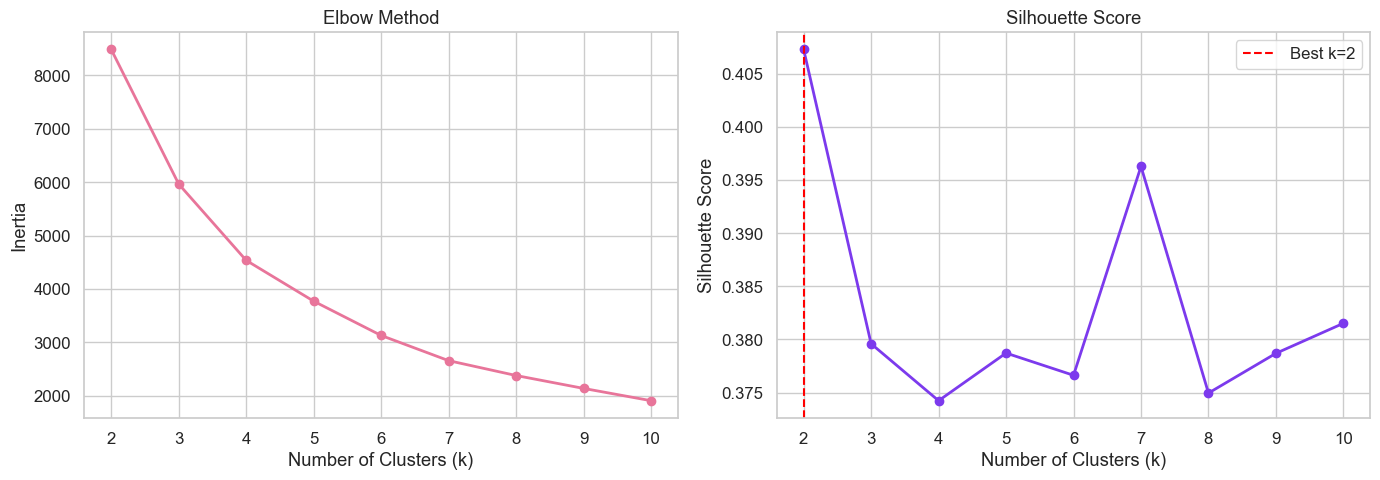


Optimal k by silhouette: 2


In [11]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "o-", color="#e8759a", linewidth=2)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(K_range, silhouettes, "o-", color="#7c3aed", linewidth=2)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nOptimal k by silhouette: {best_k}")

### 4.2 Fit Final K-Means Model

In [11]:
OPTIMAL_K = 4  # adjust based on elbow/silhouette above

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score (k={OPTIMAL_K}): {silhouette_score(X_scaled, rfm['cluster']):.3f}")
print(f"\nCluster sizes:")
rfm["cluster"].value_counts().sort_index()

Silhouette Score (k=4): 0.374

Cluster sizes:


cluster
0     947
1    1403
2    1325
3    1092
Name: count, dtype: int64

### 4.3 Cluster Profiles

In [12]:
cluster_profile = (
    rfm.groupby("cluster")
    .agg(
        count=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum"),
    )
    .round(1)
)

# Auto-label clusters
cluster_labels = {}
sorted_by_monetary = cluster_profile.sort_values("avg_monetary", ascending=False).index.tolist()
label_names = ["High-Value Active", "Loyal Mid-Tier", "Occasional Buyers", "Low-Value / Dormant"]
for idx, cluster_id in enumerate(sorted_by_monetary):
    if idx < len(label_names):
        cluster_labels[cluster_id] = label_names[idx]
    else:
        cluster_labels[cluster_id] = f"Cluster {cluster_id}"

cluster_profile["label"] = cluster_profile.index.map(cluster_labels)
rfm["cluster_label"] = rfm["cluster"].map(cluster_labels)

cluster_profile

,count,avg_recency,avg_frequency,avg_monetary,total_revenue,label
cluster,,,,,,
0,947,163.2,1.0,673.2,637527.6,Low-Value / Dormant
1,1403,102.8,2.3,5821.5,8167583.8,High-Value Active
2,1325,285.3,1.1,3113.9,4125895.0,Occasional Buyers
3,1092,91.8,1.0,3294.8,3597900.0,Loyal Mid-Tier


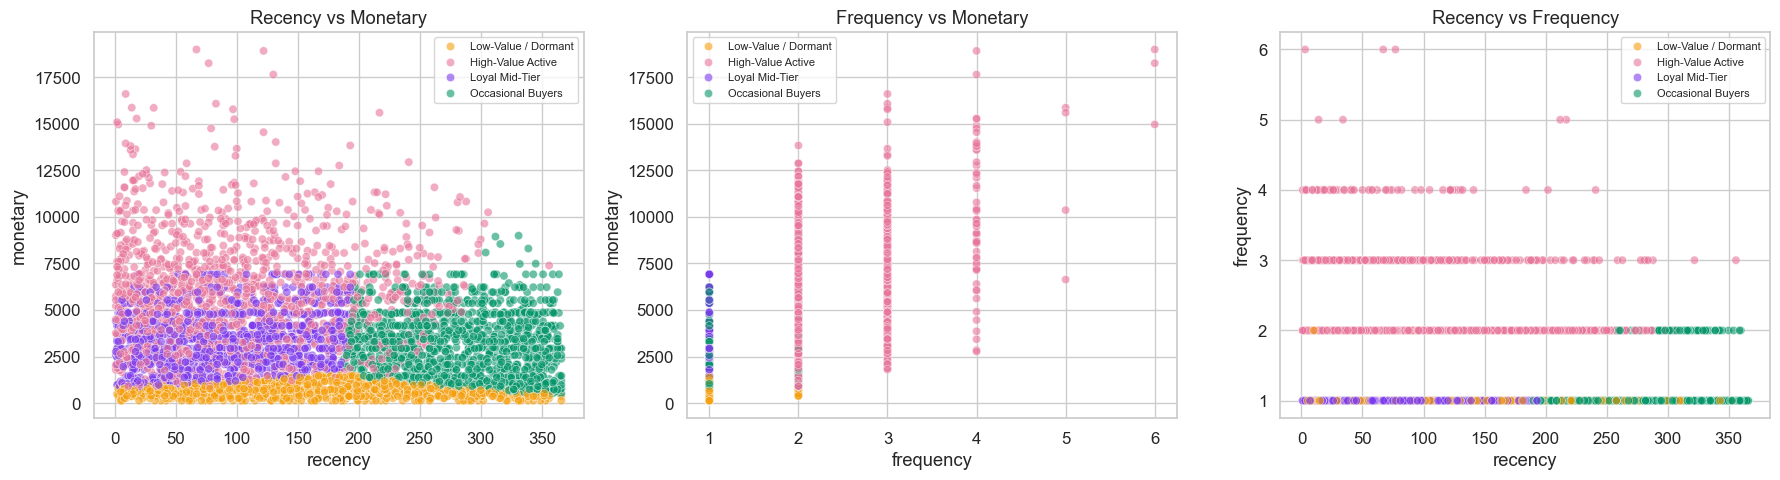

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {label: color for label, color in zip(cluster_labels.values(), ["#e8759a", "#7c3aed", "#059669", "#f59e0b", "#3b82f6"])}

for ax, (x, y, title) in zip(axes, [
    ("recency", "monetary", "Recency vs Monetary"),
    ("frequency", "monetary", "Frequency vs Monetary"),
    ("recency", "frequency", "Recency vs Frequency"),
]):
    sns.scatterplot(data=rfm, x=x, y=y, hue="cluster_label", palette=palette, alpha=0.6, ax=ax)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.4 Radar Chart — Cluster Comparison

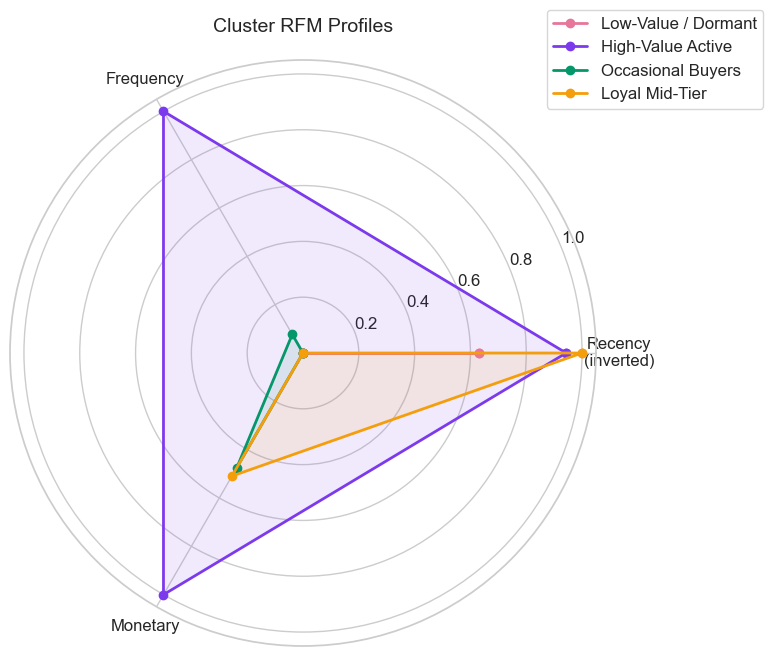

In [14]:
from math import pi

metrics = ["avg_recency", "avg_frequency", "avg_monetary"]
# Normalize to 0-1 for radar chart
radar_data = cluster_profile[metrics].copy()
# Invert recency so higher = better
radar_data["avg_recency"] = radar_data["avg_recency"].max() - radar_data["avg_recency"]
for col in metrics:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min())

categories = ["Recency\n(inverted)", "Frequency", "Monetary"]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ["#e8759a", "#7c3aed", "#059669", "#f59e0b", "#3b82f6"]

for i, (idx, row) in enumerate(radar_data.iterrows()):
    values = row.tolist()
    values += values[:1]
    label = cluster_labels.get(idx, f"Cluster {idx}")
    ax.plot(angles, values, "o-", linewidth=2, label=label, color=colors_radar[i % len(colors_radar)])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i % len(colors_radar)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title("Cluster RFM Profiles", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

### 4.5 Cross-tab: K-Means Clusters vs Traditional RFM Segments

In [15]:
cross = pd.crosstab(rfm["cluster_label"], rfm["segment"], margins=True)
cross

segment,At Risk,Can't Lose Them,Champions,Hibernating,Loyal Customers,Need Attention,New Customers,Potential Loyalists,All
cluster_label,,,,,,,,,
High-Value Active,195,17,662,0,396,12,0,121,1403
Low-Value / Dormant,0,49,0,201,0,435,181,81,947
Loyal Mid-Tier,4,0,32,5,276,9,423,343,1092
Occasional Buyers,382,85,0,726,0,130,0,2,1325
All,581,151,694,932,672,586,604,547,4767


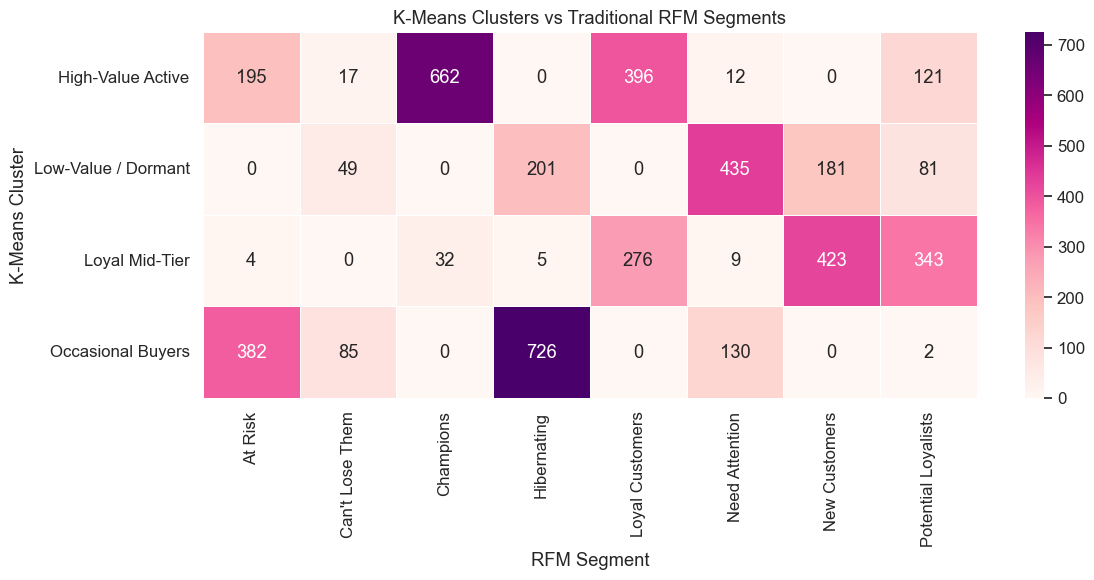

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
cross_no_margin = cross.drop("All", axis=0).drop("All", axis=1)
sns.heatmap(cross_no_margin, annot=True, fmt="d", cmap="RdPu", ax=ax, linewidths=0.5)
ax.set_title("K-Means Clusters vs Traditional RFM Segments")
ax.set_ylabel("K-Means Cluster")
ax.set_xlabel("RFM Segment")
plt.tight_layout()
plt.show()

## 5. Export Results

In [17]:
rfm.to_csv("../data/processed/rfm_customer_segments.csv", index=False)
print(f"Exported {rfm.shape[0]:,} customer segments → data/processed/rfm_customer_segments.csv")
rfm.head()

Exported 4,767 customer segments → data/processed/rfm_customer_segments.csv


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_combined,segment,cluster,cluster_label
0,1000,157,1,1100.94,3,1,2,312,312,Potential Loyalists,0,Low-Value / Dormant
1,1002,46,2,5151.88,5,4,4,544,544,Champions,1,High-Value Active
2,1003,126,1,976.70,3,1,1,311,311,Need Attention,0,Low-Value / Dormant
3,1004,121,1,1953.40,3,1,2,312,312,Potential Loyalists,3,Loyal Mid-Tier
4,1005,92,2,7395.39,4,4,5,445,445,Champions,1,High-Value Active


## 6. Business Recommendations

| Cluster | Strategy |
|---------|----------|
| **High-Value Active** | Loyalty program, exclusive offers, early access to new products |
| **Loyal Mid-Tier** | Cross-sell premium products, encourage bundle purchases |
| **Occasional Buyers** | Re-engagement campaigns, discount codes, personalized recommendations |
| **Low-Value / Dormant** | Win-back campaigns, survey for churn reasons, limited-time offers |

### Next Steps
- Feed cluster labels back into Power BI for segment-level filtering
- Build a churn prediction model using cluster features as inputs
- A/B test targeted campaigns per segment